In [30]:
import pandas as pd
import random
import scipy
import numpy as np

## 1: The UC Irvine Machine Learning data repository hosts a dataset giving various measurements of abalone at https://archive.ics.uci.edu/ml/datasets/Abalone. There are 4177 records. We will use the Length measurement. We will assume that the 4177 record is the entire population. Compute the population median. For each bootstrapping process use 3000 replicates.You need to plot the histogram of one bootstrap sample median for both (a) and (c).


In [24]:
df = pd.read_csv(r"C:\Users\Trish\Documents\CS 361\abalone\abalone.data")
df

,Sex,Length,Diameter,Height,Whole_Weight,Shcucked_Weight,Viscera_Weight,Shell_Weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [25]:
length = df['Length']

0       0.455
1       0.350
2       0.530
3       0.440
4       0.330
        ...  
4172    0.565
4173    0.590
4174    0.600
4175    0.625
4176    0.710
Name: Length, Length: 4177, dtype: float64

In [39]:
true_med = length.median()
true_med

0.545

### A. Draw 2,000 samples of 100 records at random with replacement. Use each sample to produce a bootstrap estimate of a centered 90% confidence interval for the population median. For what fraction of samples does the true population median lie inside the interval?

In [98]:
index = []
sample_med = []
interval = []
CI = []

alpha = (1-0.9)/2
lower_index = int(np.floor(alpha * 100))
upper_index = int(np.ceil((1 - alpha) * 100))
in_interval = False

for i in range(2000):
    index.append(str(i))
    s = length.sample(100, replace = False)
    s = s.sort_values().reset_index()
    CI.append([s.iat[lower_index,1],s.iat[upper_index,1]])
    if (s.iat[lower_index,1] <= true_med and s.iat[upper_index,1] >= true_med):
        in_interval = True
    else:
        in_interval = False
    interval.append(in_interval)
    sample_med.append(s['Length'].median())
    
data = {"CI_per_samp":CI,"sample_med":sample_med,"true med in interval": interval}
data = pd.DataFrame(data)
data

,CI_per_samp,sample_med,true med in interval
0,"[0.33, 0.7]",0.5500,True
1,"[0.28, 0.685]",0.5300,True
2,"[0.27, 0.7]",0.5325,True
3,"[0.285, 0.72]",0.5375,True
4,"[0.37, 0.68]",0.5475,True
...,...,...,...
1995,"[0.265, 0.68]",0.5300,True
1996,"[0.31, 0.69]",0.5500,True
1997,"[0.255, 0.705]",0.5325,True
1998,"[0.335, 0.72]",0.5375,True


In [99]:
print("fraction of true median in CI interval is",len(data[data["true med in interval"] == True])/2000)

fraction of true median in CI interval is 1.0


<Axes: >

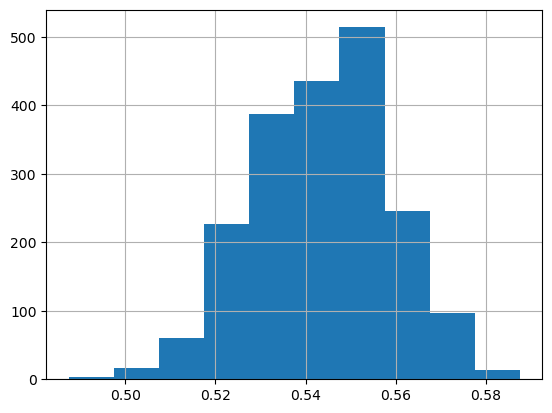

In [100]:
data['sample_med'].hist()

### C. Draw 2,000 samples of 10 records at random with replacement. Use each sample to produce a bootstrap estimate of a centered 90% confidence interval for the population median. For what fraction of samples does the true population median lie inside the interval?

In [101]:
index = []
sample_med = []
interval = []
CI = []

alpha = (1-0.9)/2
lower_index = int((alpha * 10))
upper_index = int((1 - alpha) * 10)
in_interval = False

for i in range(2000):
    index.append(str(i))
    s = length.sample(10, replace = False)
    s = s.sort_values().reset_index()
    CI.append([s.iat[lower_index,1],s.iat[upper_index,1]])
    if (s.iat[lower_index,1] <= true_med and s.iat[upper_index,1] >= true_med):
        in_interval = True
    else:
        in_interval = False
    interval.append(in_interval)
    sample_med.append(s['Length'].median())
    
data = {"CI_per_samp":CI,"sample_med":sample_med,"true med in interval": interval}
data = pd.DataFrame(data)
data

,CI_per_samp,sample_med,true med in interval
0,"[0.5, 0.71]",0.5875,True
1,"[0.265, 0.655]",0.4675,True
2,"[0.385, 0.685]",0.5525,True
3,"[0.21, 0.695]",0.5050,True
4,"[0.295, 0.74]",0.5425,True
...,...,...,...
1995,"[0.435, 0.72]",0.5475,True
1996,"[0.26, 0.675]",0.5600,True
1997,"[0.435, 0.77]",0.6050,True
1998,"[0.41, 0.76]",0.5875,True


In [102]:
print("fraction of true median in CI interval is",len(data[data["true med in interval"] == True])/2000)

fraction of true median in CI interval is 0.9985


<Axes: >

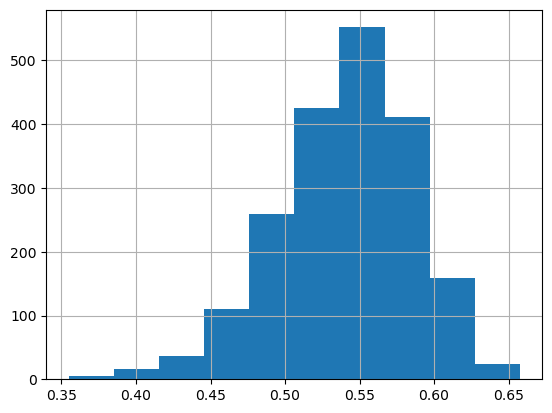

In [103]:
data['sample_med'].hist()

### D. What conclusion do you draw? 

The larger the sample sizes of what we are drawing is and the more times we replicate the process, the closer the probability of the true median falling within their defined interval is gets to 1.

## 6:  You can find a dataset giving income data for US citizens at the UC Irvine Machine Learning data archive, at http://archive.ics.uci.edu/ml/datasets/Adult. Each item consists of a set of numeric and categorical features describing a person,together with whether their annual income is larger than or smaller than 50 K$.

In [11]:
adult = pd.read_csv(r"C:\Users\Trish\Documents\CS 361\adult\adult.data")
adult
#pd.get_dummies(adult)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital--gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


### Chi-square on income and sex

In [21]:
tab1 = pd.crosstab(adult['sex'], adult['income'])
stat, p, dof, expected = scipy.stats.chi2_contingency(tab1)
print("Chi-square statistic:", stat)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:", expected)

Chi-square statistic: 1517.813409134445
P-value: 0.0
Degrees of freedom: 1
Expected frequencies: [[ 8177.24025675  2593.75974325]
 [16542.75974325  5247.24025675]]


Assess the evidence that income category is independent of gender:

Given a significance level of 0.05, the calculated p-value is smaller than the significance level. This indicates that the statistic is statistically significant. In otherwords, in the context of this dataset, the high chi square value indicates that the 2 variables are not independent.

### Chi-square on income and education level

In [22]:
tab2 = pd.crosstab(adult['education'], adult['income'])
stat, p, dof, expected = scipy.stats.chi2_contingency(tab2)
print("Chi-square statistic:", stat)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:", expected)

Chi-square statistic: 4429.653302288619
P-value: 0.0
Degrees of freedom: 15
Expected frequencies: [[ 708.3246829   224.6753171 ]
 [ 892.04877     282.95123   ]
 [ 328.72946163  104.27053837]
 [ 127.54399435   40.45600565]
 [ 252.81041737   80.18958263]
 [ 490.43702589  155.56297411]
 [ 390.22388747  123.77611253]
 [ 810.05620221  256.94379779]
 [1049.20119161  332.79880839]
 [4065.46481988 1289.53518012]
 [ 313.54565277   99.45434723]
 [7972.25883726 2528.74116274]
 [1308.08513252  414.91486748]
 [  38.71871257   12.28128743]
 [ 437.29369491  138.70630509]
 [5535.25751666 1755.74248334]]


Assess the evidence that income category is independent of education level:

Given a significance level of 0.05, the calculated p-value is smaller than the significance level. This indicates that the statistic is statistically significant. In other words, in the context of this dataset, the high chi square value indicates that the 2 variables are not independent.